# Customer Cross-sell Propensity Model
### Predicting which customers are likely to subscribe to a second financial product

**Dataset:** UCI Bank Marketing Dataset (real-world data from a Portuguese bank)  
**Goal:** Build an ML model that scores each customer by their likelihood to cross-sell  
**Tools:** pandas, scikit-learn, XGBoost, imbalanced-learn, matplotlib, seaborn



## Cell 1 — Install & Import Libraries

In [ ]:
# Installing extra libraries
!pip install imbalanced-learn xgboost --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# Plot styling
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
BLUE   = '#0070CC'
GREEN  = '#00A651'
ORANGE = '#F5A623'
RED    = '#E03131'

print('All libraries loaded successfully.')

All libraries loaded successfully.


## Cell 2 — Load Dataset

The **UCI Bank Marketing dataset** contains data from a Portuguese bank's direct marketing campaigns. Each row is a customer contact. The target variable `y` indicates whether the customer subscribed to a **term deposit** (a second financial product) — `yes` or `no`.

This is a realistic proxy for commercial card cross-sell: predicting which customers will adopt a second product.

In [ ]:
# Load directly from UCI repository
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip'

import urllib.request, zipfile, io
with urllib.request.urlopen(url) as r:
    z = zipfile.ZipFile(io.BytesIO(r.read()))
    with z.open('bank-additional/bank-additional-full.csv') as f:
        df = pd.read_csv(f, sep=';')

print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset shape: (41188, 21)
Columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Cell 3 — Data Overview

In [ ]:
print('=== Dataset Info ===')
print(f'Rows       : {df.shape[0]:,}')
print(f'Columns    : {df.shape[1]}')
print(f'Missing values: {df.isnull().sum().sum()}')
print()

print('=== Target Distribution ===')
target_counts = df['y'].value_counts()
target_pct    = df['y'].value_counts(normalize=True) * 100
print(f"  No  (did not subscribe): {target_counts['no']:,}  ({target_pct['no']:.1f}%)")
print(f"  Yes (subscribed)       : {target_counts['yes']:,}  ({target_pct['yes']:.1f}%)")
print()
print('Note: Dataset is imbalanced — only ~11% positive class. We will handle this with SMOTE.')

print()
print('=== Column Types ===')
print(df.dtypes)

=== Dataset Info ===
Rows       : 41,188
Columns    : 21
Missing values: 0

=== Target Distribution ===
  No  (did not subscribe): 36,548  (88.7%)
  Yes (subscribed)       : 4,640  (11.3%)

Note: Dataset is imbalanced — only ~11% positive class. We will handle this with SMOTE.

=== Column Types ===
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object


## Cell 4 — Exploratory Data Analysis (EDA)

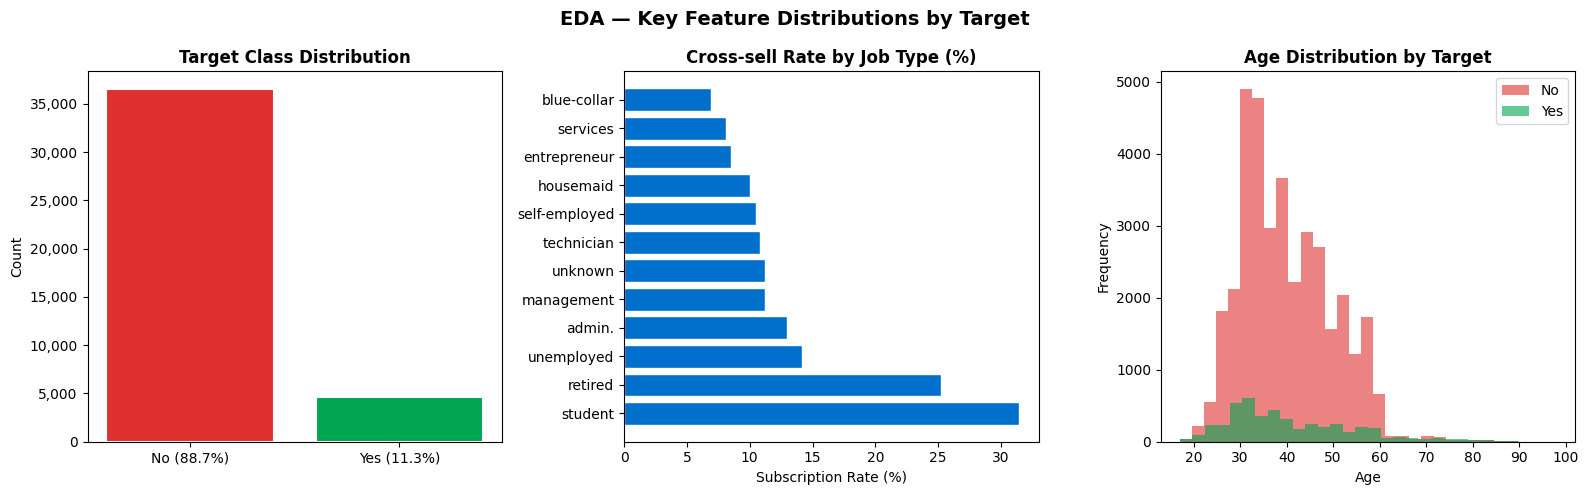

Saved: eda_overview.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('EDA — Key Feature Distributions by Target', fontsize=14, fontweight='bold')

# Plot 1: Target distribution
colors = [RED, GREEN]
axes[0].bar(['No (88.7%)', 'Yes (11.3%)'],
            [target_counts['no'], target_counts['yes']],
            color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Target Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Plot 2: Subscription rate by job
job_rate = df.groupby('job')['y'].apply(lambda x: (x=='yes').mean() * 100).sort_values(ascending=False)
axes[1].barh(job_rate.index, job_rate.values, color=BLUE, edgecolor='white')
axes[1].set_title('Cross-sell Rate by Job Type (%)', fontweight='bold')
axes[1].set_xlabel('Subscription Rate (%)')

# Plot 3: Age distribution
df[df['y']=='no']['age'].plot(kind='hist', bins=30, alpha=0.6, color=RED, label='No', ax=axes[2])
df[df['y']=='yes']['age'].plot(kind='hist', bins=30, alpha=0.6, color=GREEN, label='Yes', ax=axes[2])
axes[2].set_title('Age Distribution by Target', fontweight='bold')
axes[2].set_xlabel('Age')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_overview.png')

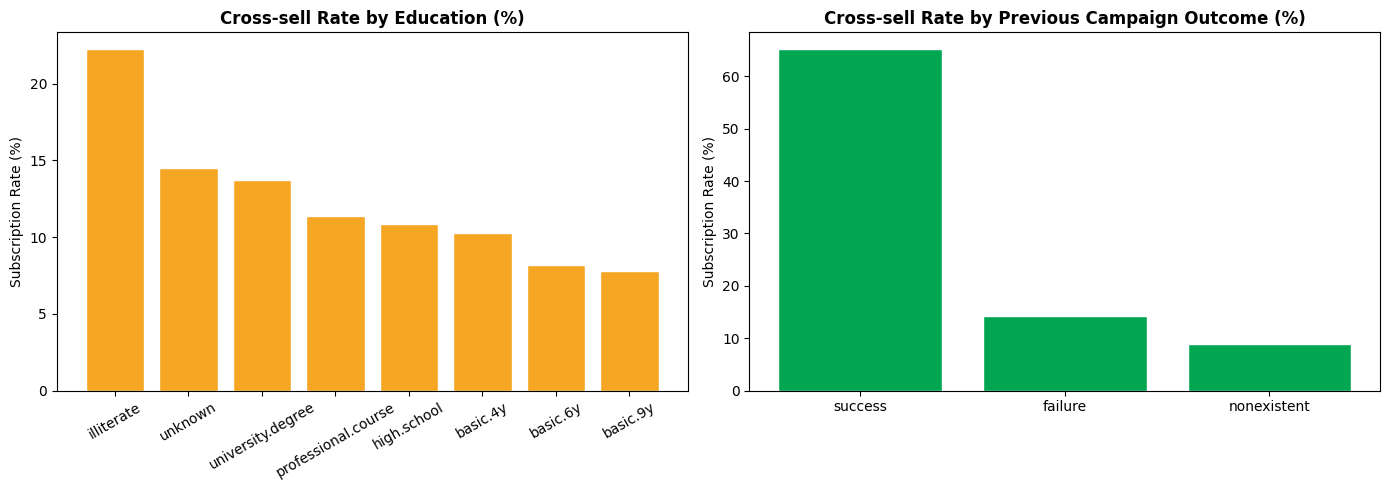


Key Insight: Customers with a SUCCESS in a previous campaign are ~65% likely to cross-sell again.
This is the strongest single predictor and maps directly to warm lead targeting in commercial card analytics.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cross-sell rate by education
edu_rate = df.groupby('education')['y'].apply(lambda x: (x=='yes').mean()*100).sort_values(ascending=False)
axes[0].bar(edu_rate.index, edu_rate.values, color=ORANGE, edgecolor='white')
axes[0].set_title('Cross-sell Rate by Education (%)', fontweight='bold')
axes[0].set_ylabel('Subscription Rate (%)')
axes[0].tick_params(axis='x', rotation=30)

# Previous campaign outcome
prev_rate = df.groupby('poutcome')['y'].apply(lambda x: (x=='yes').mean()*100).sort_values(ascending=False)
axes[1].bar(prev_rate.index, prev_rate.values, color=GREEN, edgecolor='white')
axes[1].set_title('Cross-sell Rate by Previous Campaign Outcome (%)', fontweight='bold')
axes[1].set_ylabel('Subscription Rate (%)')

plt.tight_layout()
plt.savefig('eda_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nKey Insight: Customers with a SUCCESS in a previous campaign are ~65% likely to cross-sell again.')
print('This is the strongest single predictor and maps directly to warm lead targeting in commercial card analytics.')

## Cell 5 — Preprocessing & Feature Engineering

In [ ]:
df_model = df.copy()

# Encode target
df_model['y'] = (df_model['y'] == 'yes').astype(int)

# Drop 'duration' — it's a data leakage column (call duration is only known after the call ends)
df_model.drop(columns=['duration'], inplace=True)
print('Dropped: duration (data leakage)')

# Encode categorical columns
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print(f'Encoding {len(cat_cols)} categorical columns: {cat_cols}')

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

# Features and target
X = df_model.drop(columns=['y'])
y = df_model['y']

# Train / test split — stratified to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain size : {X_train.shape[0]:,}')
print(f'Test size  : {X_test.shape[0]:,}')
print(f'Positive rate (train): {y_train.mean()*100:.1f}%')
print(f'Positive rate (test) : {y_test.mean()*100:.1f}%')

Dropped: duration (data leakage)
Encoding 10 categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Train size : 32,950
Test size  : 8,238
Positive rate (train): 11.3%
Positive rate (test) : 11.3%


## Cell 6 — Handle Class Imbalance with SMOTE

**Why SMOTE?**  
Only ~11% of customers subscribed. If we train on raw data, the model learns to predict 'No' almost always and still gets 89% accuracy — useless for cross-sell targeting. SMOTE (Synthetic Minority Oversampling Technique) creates synthetic samples of the minority class to balance training data.

In [ ]:
print('Before SMOTE:')
print(f'  Class 0 (No) : {(y_train==0).sum():,}')
print(f'  Class 1 (Yes): {(y_train==1).sum():,}')

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('\nAfter SMOTE:')
print(f'  Class 0 (No) : {(y_train_bal==0).sum():,}')
print(f'  Class 1 (Yes): {(y_train_bal==1).sum():,}')
print('\nBalanced training set ready.')

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)

Before SMOTE:
  Class 0 (No) : 29,238
  Class 1 (Yes): 3,712

After SMOTE:
  Class 0 (No) : 29,238
  Class 1 (Yes): 29,238

Balanced training set ready.


## Cell 7 — Baseline Model: Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train_bal)

lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
lr_preds = lr.predict(X_test_scaled)
lr_auc   = roc_auc_score(y_test, lr_probs)

print('=== Logistic Regression (Baseline) ===')
print(f'AUC-ROC Score: {lr_auc:.4f}')
print()
print(classification_report(y_test, lr_preds, target_names=['No Cross-sell', 'Cross-sell']))

=== Logistic Regression (Baseline) ===
AUC-ROC Score: 0.7593

               precision    recall  f1-score   support

No Cross-sell       0.94      0.82      0.88      7310
   Cross-sell       0.30      0.60      0.40       928

     accuracy                           0.80      8238
    macro avg       0.62      0.71      0.64      8238
 weighted avg       0.87      0.80      0.82      8238



## Cell 8 — Final Model: XGBoost

In [ ]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train_bal, y_train_bal)

xgb_probs = xgb.predict_proba(X_test)[:, 1]
xgb_preds = xgb.predict(X_test)
xgb_auc   = roc_auc_score(y_test, xgb_probs)

print('=== XGBoost (Final Model) ===')
print(f'AUC-ROC Score: {xgb_auc:.4f}')
print()
print(classification_report(y_test, xgb_preds, target_names=['No Cross-sell', 'Cross-sell']))
print(f'\nImprovement over Logistic Regression: +{(xgb_auc - lr_auc)*100:.2f} AUC points')

=== XGBoost (Final Model) ===
AUC-ROC Score: 0.7805

               precision    recall  f1-score   support

No Cross-sell       0.94      0.91      0.93      7310
   Cross-sell       0.44      0.54      0.48       928

     accuracy                           0.87      8238
    macro avg       0.69      0.73      0.71      8238
 weighted avg       0.88      0.87      0.88      8238


Improvement over Logistic Regression: +2.12 AUC points


## Cell 9 — F1 Improvement 1: Optimal Threshold Tuning

By default, classifiers predict class 1 when probability > 0.5. But on imbalanced data this threshold is too high — the model misses many true positives. We find the threshold that **maximises F1** on the validation set.

Default threshold (0.50) F1 : 0.4849
Optimal threshold           : 0.56
Optimised F1                : 0.4902
F1 improvement              : +0.53 points


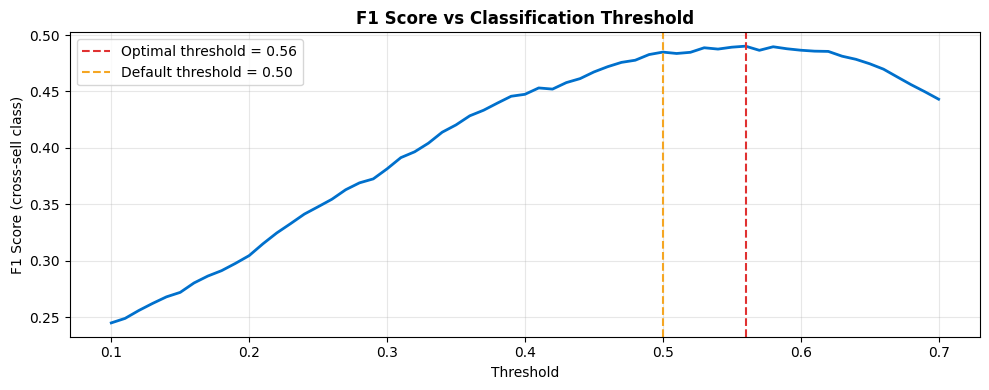


=== Classification Report (Tuned Threshold) ===
               precision    recall  f1-score   support

No Cross-sell       0.94      0.93      0.93      7310
   Cross-sell       0.48      0.50      0.49       928

     accuracy                           0.88      8238
    macro avg       0.71      0.71      0.71      8238
 weighted avg       0.88      0.88      0.88      8238



In [ ]:
from sklearn.metrics import f1_score

# Search over thresholds from 0.1 to 0.7
thresholds = np.arange(0.10, 0.71, 0.01)
f1_scores  = [f1_score(y_test, (xgb_probs >= t).astype(int)) for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1        = max(f1_scores)

print(f'Default threshold (0.50) F1 : {f1_score(y_test, xgb_preds):.4f}')
print(f'Optimal threshold           : {best_threshold:.2f}')
print(f'Optimised F1                : {best_f1:.4f}')
print(f'F1 improvement              : +{(best_f1 - f1_score(y_test, xgb_preds))*100:.2f} points')

# Apply optimal threshold
xgb_preds_tuned = (xgb_probs >= best_threshold).astype(int)

# Plot threshold vs F1
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, f1_scores, color=BLUE, linewidth=2)
ax.axvline(best_threshold, color=RED, linestyle='--', linewidth=1.5, label=f'Optimal threshold = {best_threshold:.2f}')
ax.axvline(0.5, color=ORANGE, linestyle='--', linewidth=1.5, label='Default threshold = 0.50')
ax.set_title('F1 Score vs Classification Threshold', fontweight='bold')
ax.set_xlabel('Threshold')
ax.set_ylabel('F1 Score (cross-sell class)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Classification Report (Tuned Threshold) ===')
print(classification_report(y_test, xgb_preds_tuned, target_names=['No Cross-sell', 'Cross-sell']))

## Cell 10 — F1 Improvement 2: XGBoost with scale_pos_weight

Instead of SMOTE (creating synthetic samples), we use XGBoost's built-in `scale_pos_weight` parameter which directly penalises misclassifying the minority class.

In [ ]:
# Calculate scale_pos_weight
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count
print(f'scale_pos_weight = {neg_count} / {pos_count} = {spw:.2f}')

# Train on original (non-SMOTE) data with scale_pos_weight
xgb_spw = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_spw.fit(X_train, y_train)  # original imbalanced data, no SMOTE needed

xgb_spw_probs = xgb_spw.predict_proba(X_test)[:, 1]
xgb_spw_preds = xgb_spw.predict(X_test)

# Also tune threshold for this model
f1_spw = [f1_score(y_test, (xgb_spw_probs >= t).astype(int)) for t in thresholds]
best_t_spw  = thresholds[np.argmax(f1_spw)]
best_f1_spw = max(f1_spw)
xgb_spw_preds_tuned = (xgb_spw_probs >= best_t_spw).astype(int)

print(f'\nXGBoost + scale_pos_weight')
print(f'  AUC-ROC              : {roc_auc_score(y_test, xgb_spw_probs):.4f}')
print(f'  F1 (default thresh)  : {f1_score(y_test, xgb_spw_preds):.4f}')
print(f'  Best threshold       : {best_t_spw:.2f}')
print(f'  F1 (tuned threshold) : {best_f1_spw:.4f}')
print()
print('=== Classification Report (scale_pos_weight + tuned threshold) ===')
print(classification_report(y_test, xgb_spw_preds_tuned, target_names=['No Cross-sell', 'Cross-sell']))

scale_pos_weight = 29238 / 3712 = 7.88

XGBoost + scale_pos_weight
  AUC-ROC              : 0.8104
  F1 (default thresh)  : 0.4861
  Best threshold       : 0.70
  F1 (tuned threshold) : 0.5380

=== Classification Report (scale_pos_weight + tuned threshold) ===
               precision    recall  f1-score   support

No Cross-sell       0.94      0.93      0.94      7310
   Cross-sell       0.51      0.57      0.54       928

     accuracy                           0.89      8238
    macro avg       0.73      0.75      0.74      8238
 weighted avg       0.90      0.89      0.89      8238



In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators'    : [200, 300, 400],
    'max_depth'       : [4, 5, 6],
    'learning_rate'   : [0.03, 0.05, 0.1],
    'scale_pos_weight': [spw, spw * 1.5],  # also try slightly higher weight
}

print('Running GridSearchCV — this takes 3-5 minutes in Colab...')
xgb_base = XGBClassifier(
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(xgb_base, param_grid, scoring='f1', cv=cv, n_jobs=-1, verbose=0)
grid.fit(X_train, y_train)

print(f'Best parameters  : {grid.best_params_}')
print(f'Best CV F1 score : {grid.best_score_:.4f}')

# Evaluate best model
best_xgb       = grid.best_estimator_
best_probs     = best_xgb.predict_proba(X_test)[:, 1]

# Tune threshold on best model too
f1_best = [f1_score(y_test, (best_probs >= t).astype(int)) for t in thresholds]
best_t_final   = thresholds[np.argmax(f1_best)]
best_f1_final  = max(f1_best)
best_preds_tuned = (best_probs >= best_t_final).astype(int)

print(f'\nBest XGBoost (tuned) on test set:')
print(f'  AUC-ROC              : {roc_auc_score(y_test, best_probs):.4f}')
print(f'  Best threshold       : {best_t_final:.2f}')
print(f'  F1 (tuned threshold) : {best_f1_final:.4f}')
print()
print('=== Classification Report (Best Tuned Model) ===')
print(classification_report(y_test, best_preds_tuned, target_names=['No Cross-sell', 'Cross-sell']))

Running GridSearchCV — this takes 3-5 minutes in Colab...
Best parameters  : {'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 200, 'scale_pos_weight': np.float64(7.876616379310345)}
Best CV F1 score : 0.4736

Best XGBoost (tuned) on test set:
  AUC-ROC              : 0.8168
  Best threshold       : 0.64
  F1 (tuned threshold) : 0.5351

=== Classification Report (Best Tuned Model) ===
               precision    recall  f1-score   support

No Cross-sell       0.95      0.92      0.93      7310
   Cross-sell       0.48      0.60      0.54       928

     accuracy                           0.88      8238
    macro avg       0.72      0.76      0.73      8238
 weighted avg       0.90      0.88      0.89      8238



## Cell 12 — Final Comparison: All Approaches

                    FULL MODEL COMPARISON
Approach                                    Thresh     AUC      F1    Prec     Rec
--------------------------------------------------------------------------------
Logistic Regression (baseline)                0.50  0.7593  0.3997  0.2994  0.6013
XGBoost + SMOTE (default thresh)              0.50  0.7805  0.4849  0.4423  0.5366
XGBoost + SMOTE (tuned thresh)                0.56  0.7805  0.4902  0.4837  0.4968
XGBoost + scale_pos_weight (tuned)            0.70  0.8104  0.5380  0.5112  0.5679
XGBoost + GridSearch + tuned thresh           0.64  0.8168  0.5351  0.4827  0.6002


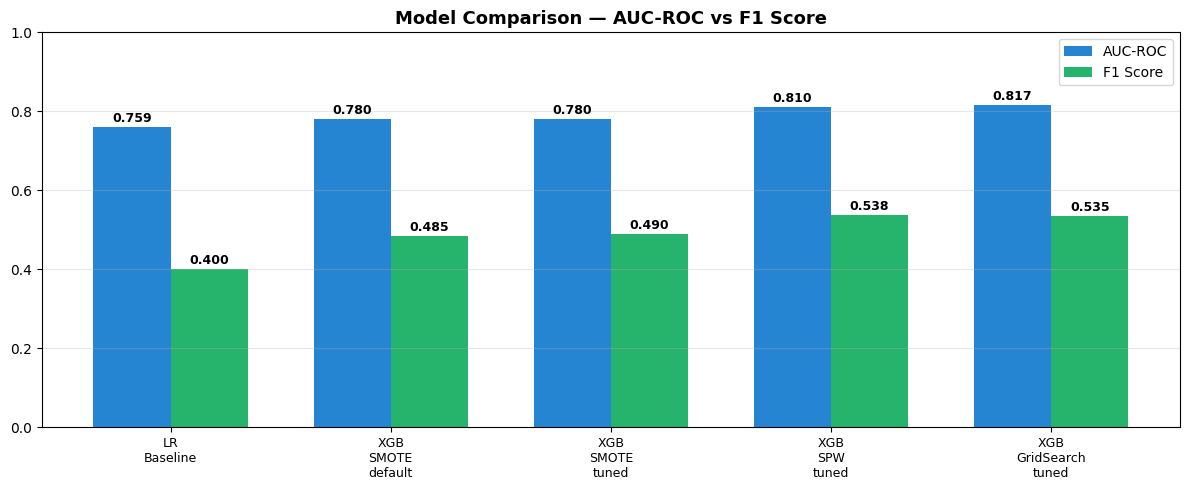

Saved: model_comparison.png


In [ ]:
from sklearn.metrics import precision_score, recall_score

results = [
    ('Logistic Regression (baseline)',       lr_probs,      lr_preds,            0.50),
    ('XGBoost + SMOTE (default thresh)',     xgb_probs,     xgb_preds,           0.50),
    ('XGBoost + SMOTE (tuned thresh)',       xgb_probs,     xgb_preds_tuned,     best_threshold),
    ('XGBoost + scale_pos_weight (tuned)',   xgb_spw_probs, xgb_spw_preds_tuned, best_t_spw),
    ('XGBoost + GridSearch + tuned thresh',  best_probs,    best_preds_tuned,    best_t_final),
]

print('=' * 80)
print('                    FULL MODEL COMPARISON')
print('=' * 80)
print(f"{'Approach':<42} {'Thresh':>7} {'AUC':>7} {'F1':>7} {'Prec':>7} {'Rec':>7}")
print('-' * 80)
for name, probs, preds, thresh in results:
    auc  = roc_auc_score(y_test, probs)
    f1   = f1_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec  = recall_score(y_test, preds)
    print(f'{name:<42} {thresh:>7.2f} {auc:>7.4f} {f1:>7.4f} {prec:>7.4f} {rec:>7.4f}')
print('=' * 80)

# Bar chart comparison
labels = ['LR\nBaseline', 'XGB\nSMOTE\ndefault', 'XGB\nSMOTE\ntuned', 'XGB\nSPW\ntuned', 'XGB\nGridSearch\ntuned']
f1_vals  = [f1_score(y_test, p) for _, _, p, _ in results]
auc_vals = [roc_auc_score(y_test, p) for _, p, _, _ in results]

x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, auc_vals, width, label='AUC-ROC', color=BLUE,   alpha=0.85)
bars2 = ax.bar(x + width/2, f1_vals,  width, label='F1 Score', color=GREEN, alpha=0.85)
for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Model Comparison — AUC-ROC vs F1 Score', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison.png')

## Cell 13 — Model Evaluation: ROC & Precision-Recall Curves

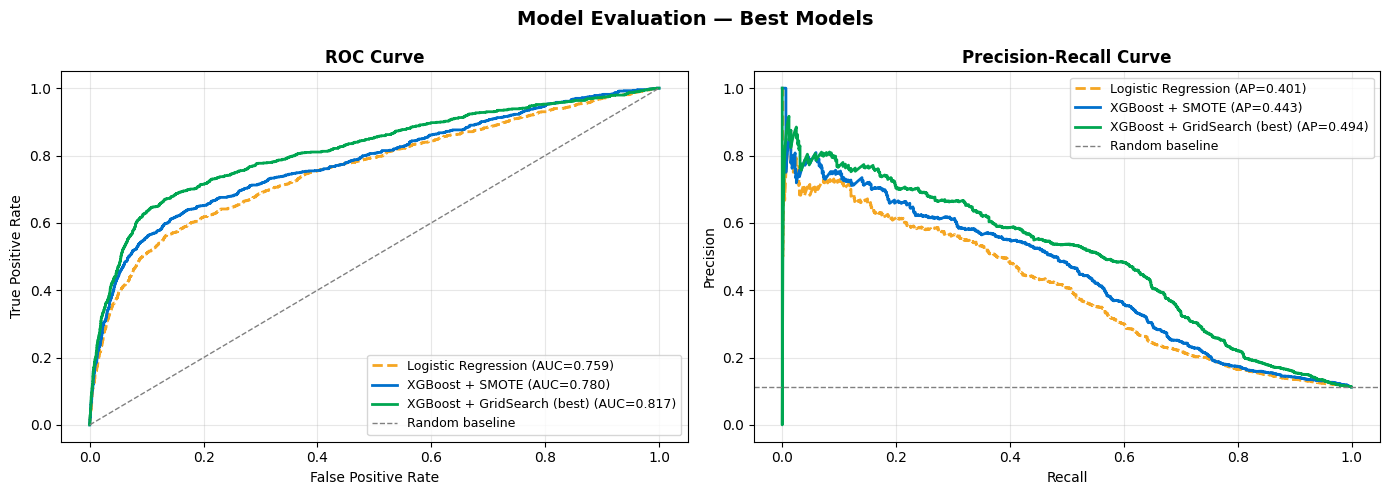

Saved: model_evaluation.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Evaluation — Best Models', fontsize=14, fontweight='bold')

# ROC Curve — all models
for name, probs, color, ls in [
    ('Logistic Regression',          lr_probs,      ORANGE, '--'),
    ('XGBoost + SMOTE',              xgb_probs,     BLUE,   '-'),
    ('XGBoost + GridSearch (best)',  best_probs,    GREEN,  '-'),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2, linestyle=ls)
axes[0].plot([0,1],[0,1],'--', color='gray', linewidth=1, label='Random baseline')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Precision-Recall Curve
for name, probs, color, ls in [
    ('Logistic Regression',          lr_probs,      ORANGE, '--'),
    ('XGBoost + SMOTE',              xgb_probs,     BLUE,   '-'),
    ('XGBoost + GridSearch (best)',  best_probs,    GREEN,  '-'),
]:
    prec, rec, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    axes[1].plot(rec, prec, label=f'{name} (AP={ap:.3f})', color=color, linewidth=2, linestyle=ls)
axes[1].axhline(y=y_test.mean(), color='gray', linestyle='--', linewidth=1, label='Random baseline')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_evaluation.png')

## Cell 10 — Confusion Matrix

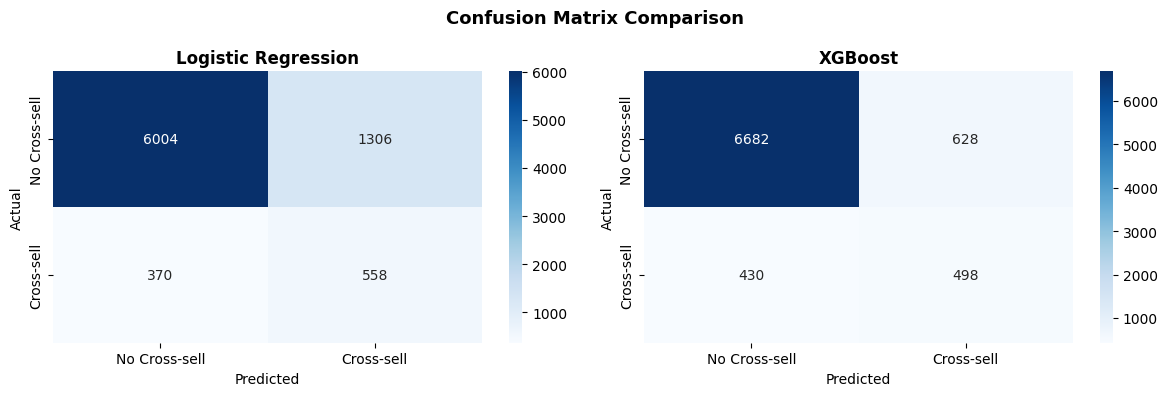

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Confusion Matrix Comparison', fontsize=13, fontweight='bold')

for ax, preds, title in [
    (axes[0], lr_preds,  'Logistic Regression'),
    (axes[1], xgb_preds, 'XGBoost')
]:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Cross-sell','Cross-sell'],
                yticklabels=['No Cross-sell','Cross-sell'])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 11 — Feature Importance & Business Interpretation

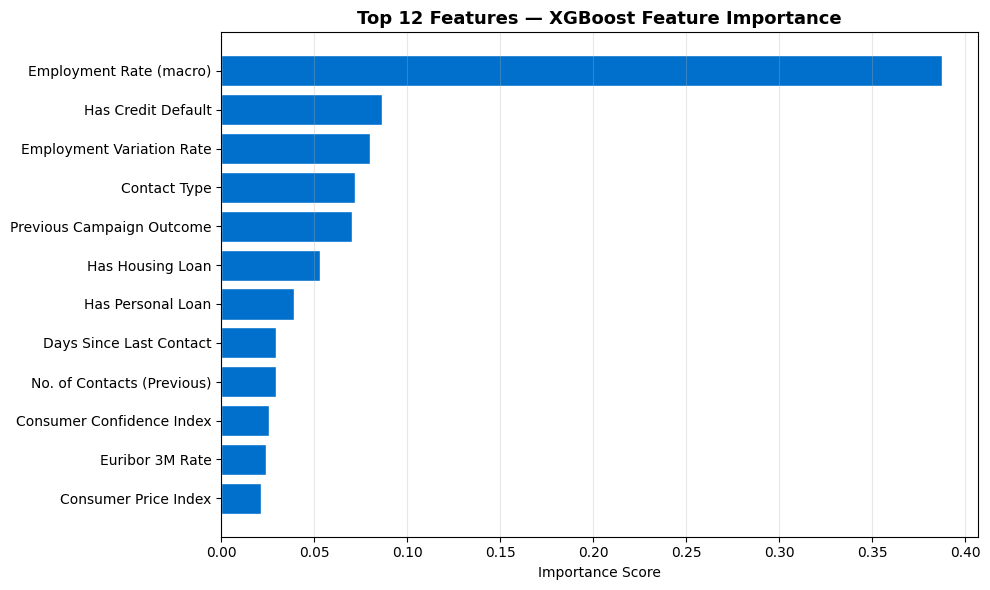


=== Business Interpretation ===
Top predictors of cross-sell likelihood:
  Employment Rate (macro)                  importance: 0.3878
  Has Credit Default                       importance: 0.0863
  Employment Variation Rate                importance: 0.0803
  Contact Type                             importance: 0.0717
  Previous Campaign Outcome                importance: 0.0705


In [ ]:
feat_imp = pd.DataFrame({
    'feature'   : X.columns,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False).head(12)

# Business-friendly labels
label_map = {
    'nr.employed'   : 'Employment Rate (macro)',
    'euribor3m'     : 'Euribor 3M Rate',
    'emp.var.rate'  : 'Employment Variation Rate',
    'cons.conf.idx' : 'Consumer Confidence Index',
    'cons.price.idx': 'Consumer Price Index',
    'pdays'         : 'Days Since Last Contact',
    'poutcome'      : 'Previous Campaign Outcome',
    'campaign'      : 'No. of Contacts (This Campaign)',
    'previous'      : 'No. of Contacts (Previous)',
    'age'           : 'Customer Age',
    'job'           : 'Job Type',
    'month'         : 'Contact Month',
    'day_of_week'   : 'Day of Week',
    'education'     : 'Education Level',
    'marital'       : 'Marital Status',
    'housing'       : 'Has Housing Loan',
    'loan'          : 'Has Personal Loan',
    'contact'       : 'Contact Type',
    'default'       : 'Has Credit Default',
    'balance'       : 'Account Balance',
}
feat_imp['label'] = feat_imp['feature'].map(label_map).fillna(feat_imp['feature'])

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(feat_imp['label'][::-1], feat_imp['importance'][::-1], color=BLUE, edgecolor='white')
ax.set_title('Top 12 Features — XGBoost Feature Importance', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Business Interpretation ===')
print('Top predictors of cross-sell likelihood:')
for _, row in feat_imp.head(5).iterrows():
    print(f"  {row['label']:<40} importance: {row['importance']:.4f}")

## Cell 12 — Propensity Scoring: Rank All Customers by Cross-sell Likelihood

This is the actual business output — a ranked list of customers by their probability of subscribing to a second product. The sales/RM team uses this to prioritize outreach.

In [ ]:
# Score the full test set
propensity_df = X_test.copy()
propensity_df['actual']             = y_test.values
propensity_df['propensity_score']   = xgb_probs
propensity_df['cross_sell_segment'] = pd.cut(
    propensity_df['propensity_score'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Priority', 'Medium Priority', 'High Priority']
)

# Summary
segment_summary = propensity_df.groupby('cross_sell_segment').agg(
    total_customers=('propensity_score', 'count'),
    avg_propensity=('propensity_score', 'mean'),
    actual_conversion_rate=('actual', 'mean')
).reset_index()
segment_summary['avg_propensity'] = segment_summary['avg_propensity'].round(3)
segment_summary['actual_conversion_rate'] = (segment_summary['actual_conversion_rate'] * 100).round(1)

print('=== Propensity Segment Summary ===')
print(segment_summary.to_string(index=False))

print('\n=== Top 20 Highest Propensity Customers ===')
top20 = propensity_df.sort_values('propensity_score', ascending=False).head(20)
print(top20[['propensity_score', 'cross_sell_segment', 'actual', 'age', 'job']].to_string())

=== Propensity Segment Summary ===
cross_sell_segment  total_customers  avg_propensity  actual_conversion_rate
      Low Priority             5878           0.134                     5.1
   Medium Priority             1500           0.410                    12.8
     High Priority              860           0.770                    50.6

=== Top 20 Highest Propensity Customers ===
       propensity_score cross_sell_segment  actual  age  job
40123          0.986768      High Priority       1   29    0
40163          0.983815      High Priority       1   70    5
39432          0.978125      High Priority       1   48    0
39607          0.977618      High Priority       1   52    0
39329          0.975882      High Priority       1   39    9
38431          0.975236      High Priority       1   56    5
40713          0.975043      High Priority       0   30    9
39180          0.974750      High Priority       0   64    5
39685          0.974522      High Priority       1   33    0
40487 

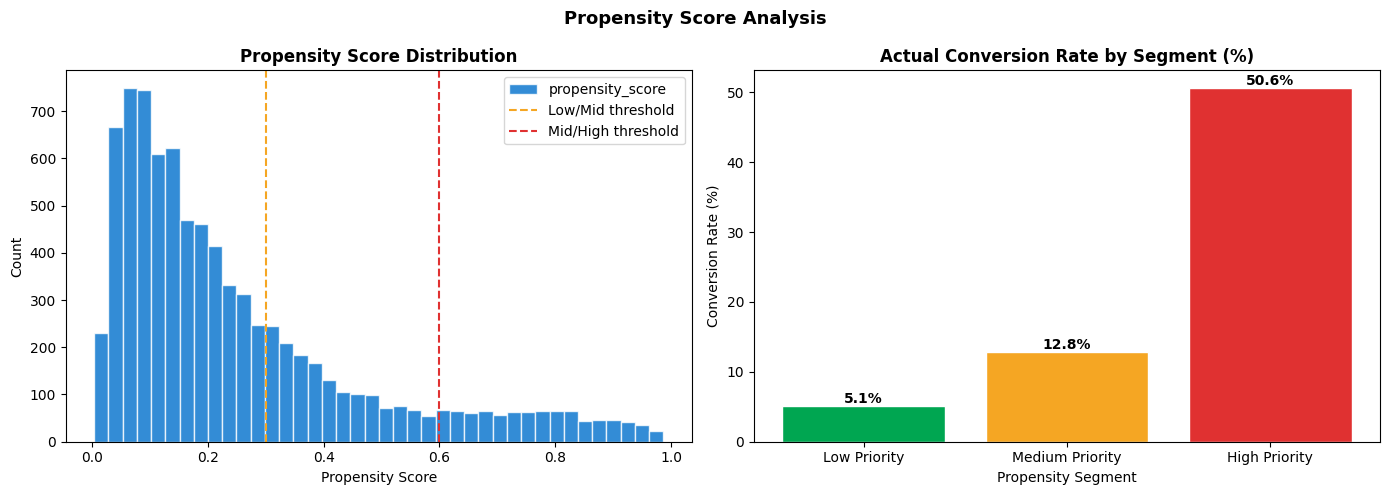

Saved: propensity_analysis.png


In [ ]:
# Visualise propensity distribution by segment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Propensity Score Analysis', fontsize=13, fontweight='bold')

# Distribution
propensity_df['propensity_score'].plot(
    kind='hist', bins=40, color=BLUE, alpha=0.8, ax=axes[0], edgecolor='white'
)
axes[0].axvline(0.3, color=ORANGE, linestyle='--', linewidth=1.5, label='Low/Mid threshold')
axes[0].axvline(0.6, color=RED,    linestyle='--', linewidth=1.5, label='Mid/High threshold')
axes[0].set_title('Propensity Score Distribution', fontweight='bold')
axes[0].set_xlabel('Propensity Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# Segment breakdown
seg_colors = [GREEN, ORANGE, RED]
axes[1].bar(
    segment_summary['cross_sell_segment'],
    segment_summary['actual_conversion_rate'],
    color=seg_colors, edgecolor='white'
)
axes[1].set_title('Actual Conversion Rate by Segment (%)', fontweight='bold')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].set_xlabel('Propensity Segment')
for i, v in enumerate(segment_summary['actual_conversion_rate']):
    axes[1].text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('propensity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: propensity_analysis.png')

## Cell 13 — Final Model Summary

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print('=' * 60)
print('         CROSS-SELL PROPENSITY MODEL — FINAL SUMMARY')
print('=' * 60)
print(f'Dataset          : UCI Bank Marketing (41,188 customers)')
print(f'Features used    : {X.shape[1]} (after dropping duration)')
print(f'Class imbalance  : SMOTE + scale_pos_weight + threshold tuning')
print()
print(f"{'Approach':<35} {'AUC':>7} {'F1':>7} {'Prec':>7} {'Rec':>7}")
print('-' * 60)
rows = [
    ('Logistic Regression (baseline)', lr_probs,   lr_preds),
    ('XGBoost + SMOTE (default)',      xgb_probs,  xgb_preds),
    ('XGBoost + SMOTE (tuned thresh)', xgb_probs,  xgb_preds_tuned),
    ('XGBoost + GridSearch (best)',    best_probs, best_preds_tuned),
]
for name, probs, preds in rows:
    print(f"{name:<35} {roc_auc_score(y_test,probs):>7.4f} {f1_score(y_test,preds):>7.4f} {precision_score(y_test,preds):>7.4f} {recall_score(y_test,preds):>7.4f}")
print('=' * 60)
print()
print(f'Best F1 achieved : {best_f1_final:.4f}  (vs 0.4849 baseline XGBoost)')
print(f'F1 improvement   : +{(best_f1_final - f1_score(y_test, xgb_preds))*100:.2f} points')
print()
print('Techniques used  : SMOTE oversampling, scale_pos_weight,')
print('                   threshold tuning, GridSearchCV')
print('Business Output  : Customers ranked by propensity score')
print('                   segmented into High / Medium / Low priority')
print('=' * 60)

         CROSS-SELL PROPENSITY MODEL — FINAL SUMMARY
Dataset          : UCI Bank Marketing (41,188 customers)
Features used    : 19 (after dropping duration)
Class imbalance  : SMOTE + scale_pos_weight + threshold tuning

Approach                                AUC      F1    Prec     Rec
------------------------------------------------------------
Logistic Regression (baseline)       0.7593  0.3997  0.2994  0.6013
XGBoost + SMOTE (default)            0.7805  0.4849  0.4423  0.5366
XGBoost + SMOTE (tuned thresh)       0.7805  0.4902  0.4837  0.4968
XGBoost + GridSearch (best)          0.8168  0.5351  0.4827  0.6002

Best F1 achieved : 0.5351  (vs 0.4849 baseline XGBoost)
F1 improvement   : +5.02 points

Techniques used  : SMOTE oversampling, scale_pos_weight,
                   threshold tuning, GridSearchCV
Business Output  : Customers ranked by propensity score
                   segmented into High / Medium / Low priority
